
=== FOLD 1/3 ===


Best Val F1: 0.3054

=== FOLD 2/3 ===


Best Val F1: 0.3635

=== FOLD 3/3 ===


Best Val F1: 0.3469

Generazione Grafici...


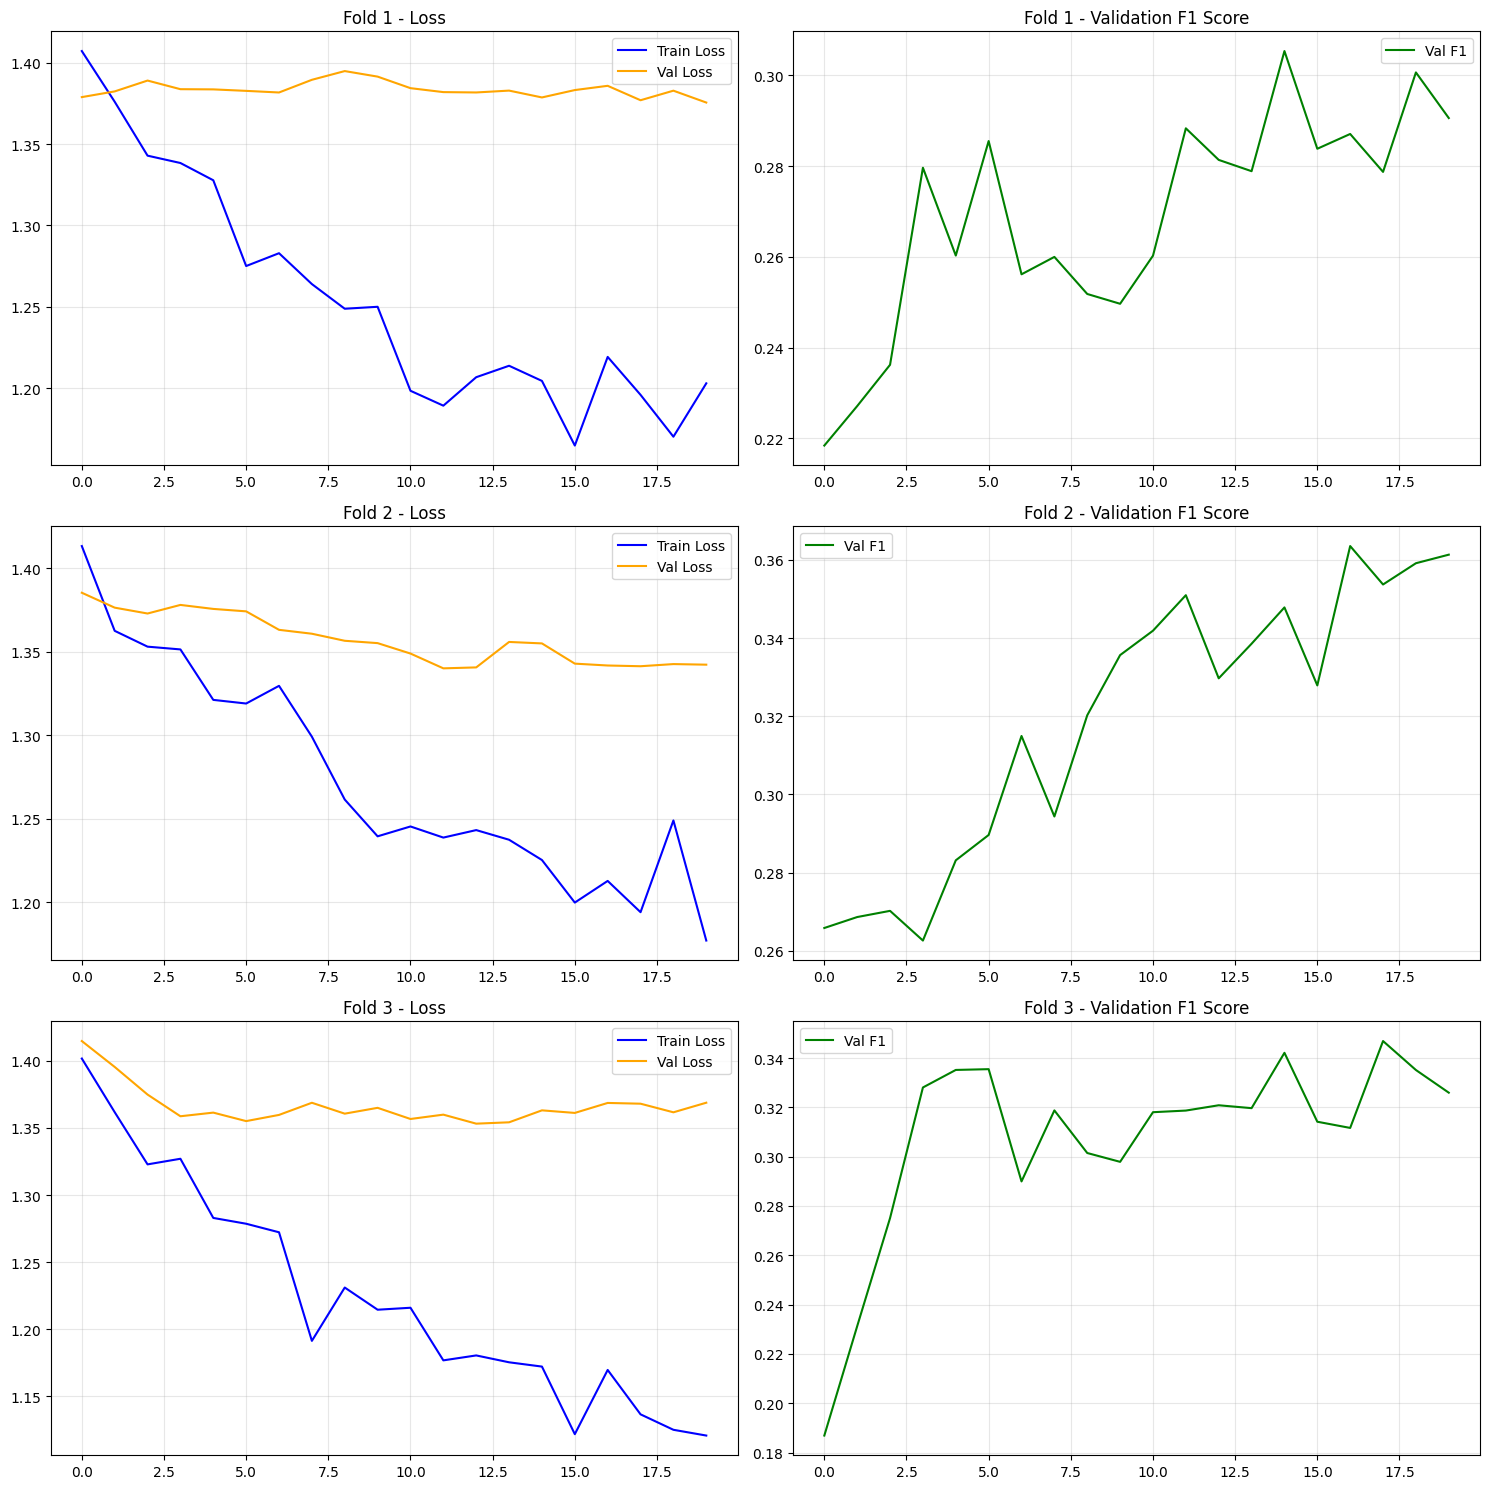

Generazione Matrice di Confusione Globale...


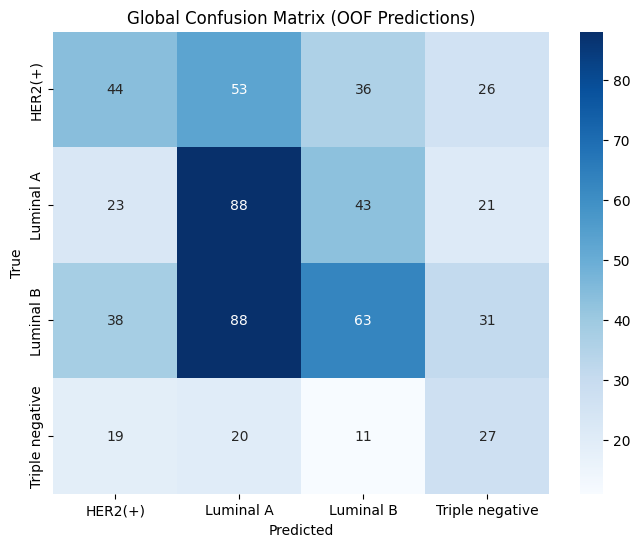


Generazione Submission (Ensemble + TTA)...


100%|██████████| 15/15 [00:17<00:00,  1.18s/it]

File submission.csv salvato.


In [4]:
import os
import cv2
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. CONFIGURAZIONE ROBUSTA ---
def find_paths():
    start_dir = "/kaggle/input"
    base_path = None
    # Trova la root in base al csv delle label
    for root, dirs, files in os.walk(start_dir):
        if "train_labels.csv" in files:
            base_path = root
            break
    if base_path is None: base_path = "/kaggle/input/dataset" 

    paths = {
        'labels': os.path.join(base_path, "train_labels.csv"),
        'train_img': os.path.join(base_path, "train_data/images"),
        'train_mask': os.path.join(base_path, "train_data/masks"),
        'test_img': os.path.join(base_path, "test_data/images"),
        'test_mask': os.path.join(base_path, "test_data/masks")
    }
    # Fallback ricerca test images
    if not os.path.exists(paths['test_img']):
        for root, dirs, files in os.walk(start_dir):
            if root.endswith("test_data/images") or (os.path.basename(root) == "images" and "test_data" in os.path.dirname(root)):
                if any(f.endswith('.png') for f in files):
                    paths['test_img'] = root
                    paths['test_mask'] = root.replace("images", "masks")
                    break
    return paths

PATHS = find_paths()
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Hyperparameters
IMG_SIZE = 256
BATCH_SIZE = 32
N_FOLDS = 3
EPOCHS = 20
LR = 1e-4

# --- 2. DATASET ---
def get_bbox_from_mask(mask):
    if np.sum(mask) == 0: return None
    rows, cols = np.where(mask > 0)
    return np.min(rows), np.max(rows), np.min(cols), np.max(cols)

class TissueDataset(Dataset):
    def __init__(self, dataframe, img_dir, mask_dir, transform=None, is_test=False):
        self.df = dataframe
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.transform = transform
        self.is_test = is_test

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_name = row['sample_index'] if not self.is_test else row['filename']
        mask_name = img_name.replace("img", "mask")
        
        img_path = os.path.join(self.img_dir, img_name)
        mask_path = os.path.join(self.mask_dir, mask_name)
        
        try:
            image = cv2.imread(img_path)
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        except Exception:
            image = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
            mask = None

        if mask is not None:
            bbox = get_bbox_from_mask(mask)
            if bbox:
                y_min, y_max, x_min, x_max = bbox
                image = image[y_min:y_max+1, x_min:x_max+1]
        
        image = Image.fromarray(image)
        if self.transform: image = self.transform(image)
        
        if self.is_test: return image, img_name
        else: return image, torch.tensor(row['label_encoded'], dtype=torch.long)

def get_transforms():
    train_trans = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomRotation(90),
        transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    val_trans = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    return train_trans, val_trans

# --- 3. MODELLO ---
def get_model(num_classes):
    model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
    model.classifier[1] = nn.Sequential(
        nn.Dropout(0.4),
        nn.Linear(model.classifier[1].in_features, num_classes)
    )
    return model.to(DEVICE)

# --- 4. TRAINING ENGINE (SINGLE FOLD) ---
def train_fold(fold, train_idx, val_idx, df, le):
    print(f"\n=== FOLD {fold+1}/{N_FOLDS} ===")
    
    train_df = df.iloc[train_idx].reset_index(drop=True)
    val_df = df.iloc[val_idx].reset_index(drop=True)
    
    # Weighted Sampler specifico per questo fold
    class_counts = train_df['label_encoded'].value_counts().sort_index().values
    class_weights = 1. / class_counts
    sample_weights = [class_weights[l] for l in train_df['label_encoded']]
    sampler = WeightedRandomSampler(sample_weights, len(sample_weights))
    
    train_trans, val_trans = get_transforms()
    train_loader = DataLoader(TissueDataset(train_df, PATHS['train_img'], PATHS['train_mask'], train_trans), 
                              batch_size=BATCH_SIZE, sampler=sampler, num_workers=2)
    val_loader = DataLoader(TissueDataset(val_df, PATHS['train_img'], PATHS['train_mask'], val_trans), 
                            batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
    
    model = get_model(len(le.classes_))
    optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-2)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
    
    history = {'t_loss': [], 'v_loss': [], 't_f1': [], 'v_f1': []}
    best_f1 = 0.0
    best_preds = []
    best_targets = []
    
    for epoch in range(EPOCHS):
        model.train()
        t_loss_accum = 0.0
        # Train Loop
        for imgs, lbls in tqdm(train_loader, desc=f"Ep {epoch+1}", leave=False):
            imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
            optimizer.zero_grad()
            out = model(imgs)
            loss = criterion(out, lbls)
            loss.backward()
            optimizer.step()
            t_loss_accum += loss.item()
        
        scheduler.step()
        
        # Validation Loop
        model.eval()
        v_loss_accum = 0.0
        preds, targets = [], []
        
        # Calcolo F1 su Train (approx) e Val
        with torch.no_grad():
            for imgs, lbls in val_loader:
                imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
                out = model(imgs)
                loss = criterion(out, lbls)
                v_loss_accum += loss.item()
                preds.extend(out.argmax(1).cpu().numpy())
                targets.extend(lbls.cpu().numpy())
        
        t_loss = t_loss_accum / len(train_loader)
        v_loss = v_loss_accum / len(val_loader)
        v_f1 = f1_score(targets, preds, average='macro')
        
        # Salvataggio metriche
        history['t_loss'].append(t_loss)
        history['v_loss'].append(v_loss)
        history['v_f1'].append(v_f1)
        
        if v_f1 > best_f1:
            best_f1 = v_f1
            best_preds = preds
            best_targets = targets
            torch.save(model.state_dict(), f"model_fold_{fold}.pth")
            
    print(f"Best Val F1: {best_f1:.4f}")
    return history, best_targets, best_preds

# --- 5. EXECUTION & PLOTTING ---
def run_full_pipeline():
    # 1. Caricamento Dati
    df = pd.read_csv(PATHS['labels'])
    valid_mask = df['sample_index'].apply(lambda x: os.path.exists(os.path.join(PATHS['train_img'], x)))
    df = df[valid_mask].reset_index(drop=True)
    
    le = LabelEncoder()
    df['label_encoded'] = le.fit_transform(df['label'])
    
    # 2. K-Fold Training
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
    all_histories = []
    global_targets = []
    global_preds = []
    
    for fold, (train_idx, val_idx) in enumerate(skf.split(df, df['label_encoded'])):
        hist, targets, preds = train_fold(fold, train_idx, val_idx, df, le)
        all_histories.append(hist)
        global_targets.extend(targets)
        global_preds.extend(preds)
        
    # 3. Plotting
    print("\nGenerazione Grafici...")
    fig, axes = plt.subplots(N_FOLDS, 2, figsize=(15, 5 * N_FOLDS))
    if N_FOLDS == 1: axes = [axes] # Handle single fold case
    
    for i, h in enumerate(all_histories):
        # Loss Curve
        ax_loss = axes[i][0]
        ax_loss.plot(h['t_loss'], label='Train Loss', color='blue')
        ax_loss.plot(h['v_loss'], label='Val Loss', color='orange')
        ax_loss.set_title(f'Fold {i+1} - Loss')
        ax_loss.legend()
        ax_loss.grid(True, alpha=0.3)
        
        # F1 Curve (solo Val salvata per pulizia, se vuoi train f1 va aggiunta nel loop)
        ax_f1 = axes[i][1]
        ax_f1.plot(h['v_f1'], label='Val F1', color='green')
        ax_f1.set_title(f'Fold {i+1} - Validation F1 Score')
        ax_f1.legend()
        ax_f1.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # 4. Global Confusion Matrix
    print("Generazione Matrice di Confusione Globale...")
    cm = confusion_matrix(global_targets, global_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title('Global Confusion Matrix (OOF Predictions)')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    return le

# --- 6. SUBMISSION ---
def generate_submission_ensemble(le):
    print("\nGenerazione Submission (Ensemble + TTA)...")
    test_files = [f for f in os.listdir(PATHS['test_img']) if f.endswith('.png')]
    test_df = pd.DataFrame({'filename': test_files})
    
    _, val_trans = get_transforms()
    test_ds = TissueDataset(test_df, PATHS['test_img'], PATHS['test_mask'], val_trans, is_test=True)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
    
    # Load Models
    models_list = []
    for i in range(N_FOLDS):
        m = get_model(len(le.classes_))
        m.load_state_dict(torch.load(f"model_fold_{i}.pth"))
        m.eval()
        models_list.append(m)
        
    preds, fnames = [], []
    
    with torch.no_grad():
        for imgs, names in tqdm(test_loader):
            imgs = imgs.to(DEVICE)
            # TTA: Original + Flip
            imgs_flip = torch.flip(imgs, [3])
            
            avg_probs = torch.zeros((imgs.size(0), len(le.classes_))).to(DEVICE)
            
            for model in models_list:
                p1 = torch.softmax(model(imgs), dim=1)
                p2 = torch.softmax(model(imgs_flip), dim=1)
                avg_probs += (p1 + p2) / 2.0
            
            avg_probs /= N_FOLDS
            preds.extend(le.inverse_transform(avg_probs.argmax(1).cpu().numpy()))
            fnames.extend(names)
            
    pd.DataFrame({'sample_index': fnames, 'label': preds}).to_csv('submission.csv', index=False)
    print("File submission.csv salvato.")

if __name__ == "__main__":
    le = run_full_pipeline()
    generate_submission_ensemble(le)